# Формулы и код к лекции 2

Этот ноутбук нужен не для большой практики, а для очень медленного показа новичкам.

## Что здесь происходит

- берем формулу из презентации;
- показываем, что она значит словами;
- пишем минимальный код;
- смотрим на результат.

Идея: чтобы студент видел, что формула и код — это одна и та же история, просто на двух языках.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="deep")

In [2]:
def mse_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


def mae_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def logloss_manual(y_true, prob):
    y_true = np.asarray(y_true, dtype=float)
    prob = np.clip(np.asarray(prob, dtype=float), 1e-6, 1 - 1e-6)
    return -np.mean(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))


def sigmoid(z):
    z = np.clip(z, -30, 30)
    return 1 / (1 + np.exp(-z))


def add_bias(X):
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return np.column_stack([np.ones(len(X)), X])


def manual_linear_weights(X, y):
    Xb = add_bias(X)
    y = np.asarray(y, dtype=float)
    return np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y


def manual_linear_predict(X, w):
    return add_bias(X) @ w


def fit_logistic_manual(X, y, lr=0.2, steps=1000):
    Xb = add_bias(X)
    y = np.asarray(y, dtype=float)
    w = np.zeros(Xb.shape[1])
    history = []
    for step in range(steps):
        p = sigmoid(Xb @ w)
        grad = Xb.T @ (p - y) / len(y)
        w -= lr * grad
        if step % 100 == 0 or step == steps - 1:
            history.append(logloss_manual(y, p))
    return w, history


def predict_logistic_manual(X, w):
    return sigmoid(add_bias(X) @ w)

## 1. Линейная модель как формула

Формула:

$$
\hat{y} = w_0 + w_1 x
$$

Что это значит:

- `x` — признак;
- `w_0` — сдвиг;
- `w_1` — наклон прямой.

Сейчас сгенерируем игрушечные данные, где настоящая зависимость действительно линейная.

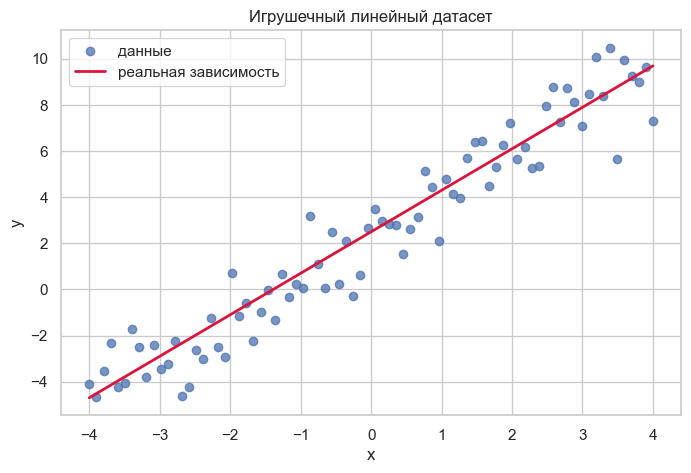

In [3]:
n = 80
X = np.linspace(-4, 4, n)
y_true_line = 2.5 + 1.8 * X
y = y_true_line + np.random.normal(0, 1.2, size=n)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.75, label="данные")
plt.plot(X, y_true_line, color="crimson", linewidth=2, label="реальная зависимость")
plt.title("Игрушечный линейный датасет")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 2. Ошибка, residual и MSE

Формулы:

$$
e_i = y_i - \hat{y}_i
$$

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Сначала специально возьмем неидеальную прямую руками и посмотрим, как считается ошибка.

MAE: 1.014
MSE: 1.615


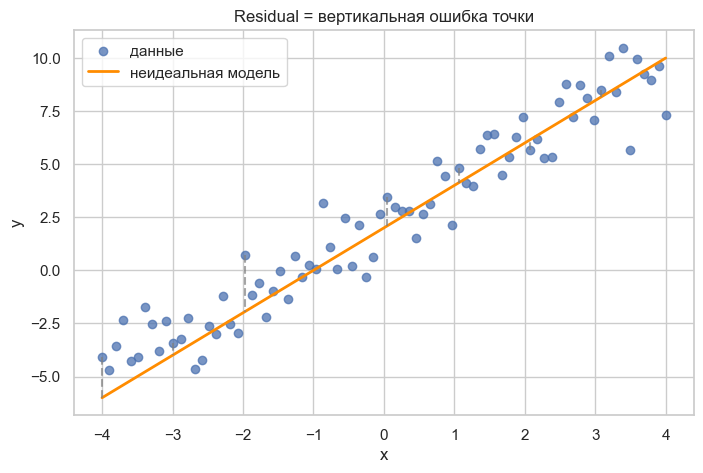

In [ ]:
w0_demo = 1.0
w1_demo = 1.2
y_pred_demo = w0_demo + w1_demo * X

print("MAE:", round(mae_manual(y, y_pred_demo), 3))
print("MSE:", round(mse_manual(y, y_pred_demo), 3))

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.75, label="данные")
plt.plot(X, y_pred_demo, color="darkorange", linewidth=2, label="неидеальная модель")

for i in range(0, len(X), 10):
    plt.plot([X[i], X[i]], [y[i], y_pred_demo[i]], color="gray", linestyle="--", alpha=0.7)

plt.title("Residual = вертикальная ошибка точки")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 3. Ручная линейная регрессия через формулу

Формула из лекции:

$$
w^* = (X^T X)^{-1} X^T y
$$

В коде это означает:

1. добавить столбец единиц для bias;
2. собрать матрицу признаков;
3. вычислить веса;
4. подставить их обратно в формулу предсказания.

Ручные веса: [2.3514 1.8142]
sklearn intercept, coef: 2.3514 1.8142
Максимальная разница предсказаний: 0.0


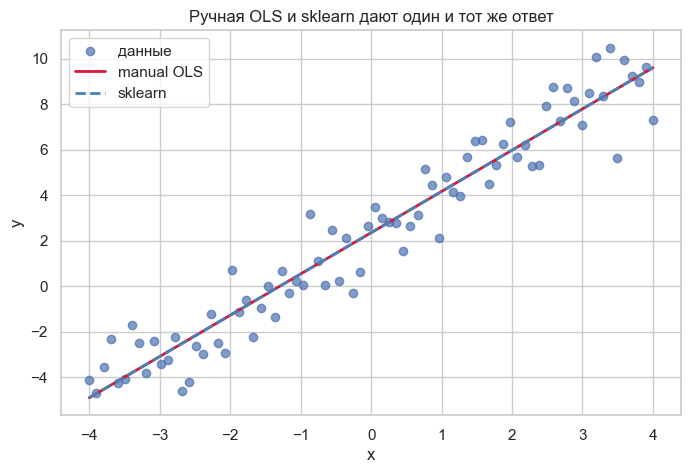

In [5]:
w_manual = manual_linear_weights(X, y)
y_pred_manual = manual_linear_predict(X, w_manual)

sk_model = LinearRegression()
sk_model.fit(X.reshape(-1, 1), y)
y_pred_sklearn = sk_model.predict(X.reshape(-1, 1))

print("Ручные веса:", np.round(w_manual, 4))
print("sklearn intercept, coef:", round(sk_model.intercept_, 4), round(sk_model.coef_[0], 4))
print("Максимальная разница предсказаний:", round(np.max(np.abs(y_pred_manual - y_pred_sklearn)), 8))

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, label="данные")
plt.plot(X, y_pred_manual, color="crimson", linewidth=2, label="manual OLS")
plt.plot(X, y_pred_sklearn, color="steelblue", linewidth=2, linestyle="--", label="sklearn")
plt.title("Ручная OLS и sklearn дают один и тот же ответ")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 4. Почему выбросы болезненны для MSE

MSE использует квадрат ошибки, поэтому редкие большие ошибки влияют особенно сильно.

Добавим несколько выбросов и посмотрим, как изменится прямая.

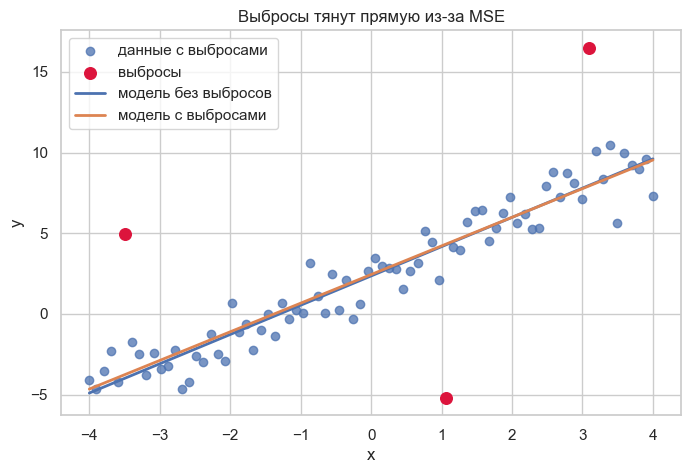

In [6]:
y_out = y.copy()
outlier_idx = [5, 50, 70]
y_out[outlier_idx] += np.array([9, -10, 8])

w_clean = manual_linear_weights(X, y)
w_out = manual_linear_weights(X, y_out)

plt.figure(figsize=(8, 5))
plt.scatter(X, y_out, alpha=0.75, label="данные с выбросами")
plt.scatter(X[outlier_idx], y_out[outlier_idx], color="crimson", s=70, label="выбросы")
plt.plot(X, manual_linear_predict(X, w_clean), linewidth=2, label="модель без выбросов")
plt.plot(X, manual_linear_predict(X, w_out), linewidth=2, label="модель с выбросами")
plt.title("Выбросы тянут прямую из-за MSE")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 5. Bernoulli и сигмоида

Для бинарной цели предполагаем:

$$
y \sim Bernoulli(p)
$$

И делаем линейным логит:

$$
\log \frac{p}{1-p} = w^T x
$$

Отсюда получается сигмоида:

$$
p(x) = \sigma(w^T x) = \frac{1}{1 + e^{-w^T x}}
$$

Посмотрим на нее глазами.

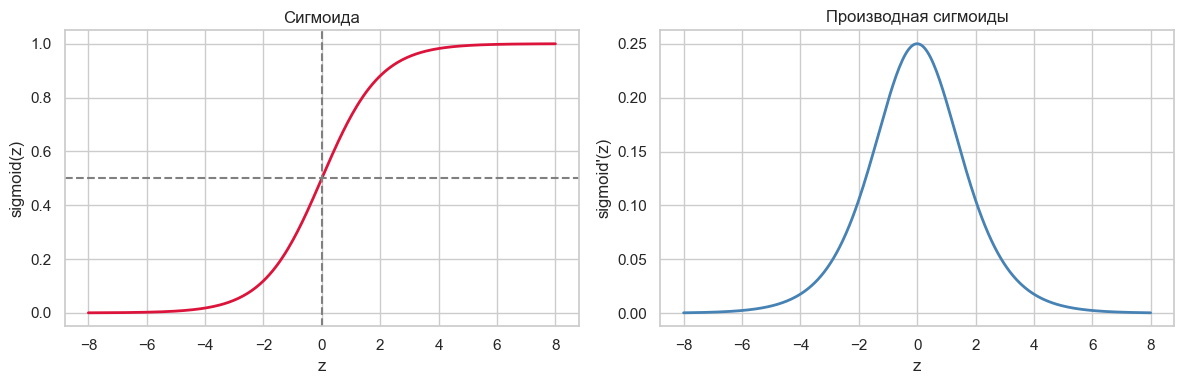

In [7]:
z = np.linspace(-8, 8, 300)
sig = sigmoid(z)
sig_der = sig * (1 - sig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(z, sig, color="crimson", linewidth=2)
axes[0].axhline(0.5, color="gray", linestyle="--")
axes[0].axvline(0, color="gray", linestyle="--")
axes[0].set_title("Сигмоида")
axes[0].set_xlabel("z")
axes[0].set_ylabel("sigmoid(z)")

axes[1].plot(z, sig_der, color="steelblue", linewidth=2)
axes[1].set_title("Производная сигмоиды")
axes[1].set_xlabel("z")
axes[1].set_ylabel("sigmoid'(z)")

plt.tight_layout()
plt.show()

## 6. Cross-entropy на маленьком примере

Формула:

$$
\text{BCE} = -\frac{1}{n}\sum_{i=1}^{n} \left[y_i \log p_i + (1-y_i) \log(1-p_i)\right]
$$

Сейчас посмотрим на нее не на абстракции, а на маленьком массиве.

In [8]:
y_small = np.array([1, 1, 0, 0, 1])
p_good = np.array([0.95, 0.8, 0.1, 0.2, 0.9])
p_bad = np.array([0.55, 0.52, 0.45, 0.48, 0.51])
p_confident_wrong = np.array([0.05, 0.2, 0.9, 0.8, 0.1])

print("Good probabilities log-loss:", round(logloss_manual(y_small, p_good), 4))
print("Uncertain probabilities log-loss:", round(logloss_manual(y_small, p_bad), 4))
print("Confident wrong probabilities log-loss:", round(logloss_manual(y_small, p_confident_wrong), 4))

Good probabilities log-loss: 0.1417
Uncertain probabilities log-loss: 0.6354
Confident wrong probabilities log-loss: 2.164


## 7. Игрушечная классификация

Теперь сделаем очень маленькую бинарную задачу, чтобы вручную обучить логистическую регрессию.

Здесь идея такая:

- линейная регрессия может давать числа вне `[0, 1]`;
- логистическая регрессия выдает вероятности;
- manual logistic и sklearn logistic должны давать близкий результат.

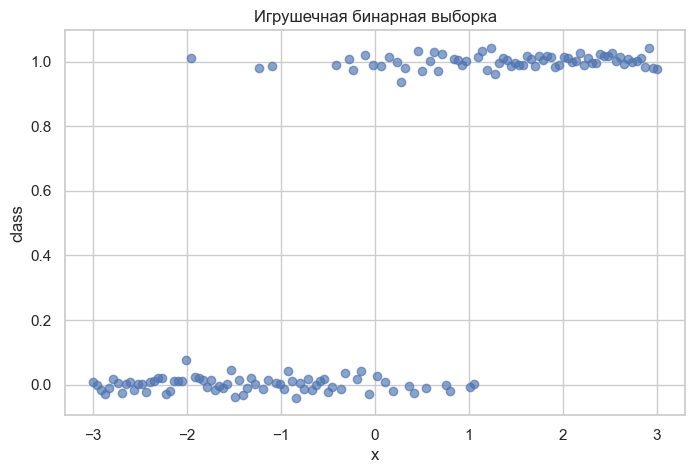

In [9]:
x1 = np.linspace(-3, 3, 140)
true_prob = sigmoid(2.2 * x1 - 0.4)
y_bin = (np.random.rand(len(x1)) < true_prob).astype(int)

plt.figure(figsize=(8, 5))
plt.scatter(x1, y_bin + np.random.normal(0, 0.02, size=len(y_bin)), alpha=0.65)
plt.title("Игрушечная бинарная выборка")
plt.xlabel("x")
plt.ylabel("class")
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    x1.reshape(-1, 1),
    y_bin,
    train_size=0.8,
    random_state=42,
    stratify=y_bin,
)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1.0
X_train_std = (X_train - mean) / std
X_test_std = (X_test - mean) / std

w_log_manual, history = fit_logistic_manual(X_train_std, y_train, lr=0.25, steps=1400)
p_manual = predict_logistic_manual(X_test_std, w_log_manual)
pred_manual = (p_manual >= 0.5).astype(int)

log_sklearn = LogisticRegression(max_iter=3000)
log_sklearn.fit(X_train_std, y_train)
p_sklearn = log_sklearn.predict_proba(X_test_std)[:, 1]
pred_sklearn = (p_sklearn >= 0.5).astype(int)

lin_bad = LinearRegression()
lin_bad.fit(X_train_std, y_train)
p_linear = np.clip(lin_bad.predict(X_test_std), 0, 1)
pred_linear = (p_linear >= 0.5).astype(int)

result_cls = pd.DataFrame([
    {
        "model": "LinearRegression + clip",
        "Accuracy": np.mean(pred_linear == y_test),
        "ROC_AUC": roc_auc_score(y_test, p_linear),
        "LogLoss": logloss_manual(y_test, p_linear),
    },
    {
        "model": "Manual logistic",
        "Accuracy": np.mean(pred_manual == y_test),
        "ROC_AUC": roc_auc_score(y_test, p_manual),
        "LogLoss": logloss_manual(y_test, p_manual),
    },
    {
        "model": "sklearn logistic",
        "Accuracy": np.mean(pred_sklearn == y_test),
        "ROC_AUC": roc_auc_score(y_test, p_sklearn),
        "LogLoss": logloss_manual(y_test, p_sklearn),
    },
]).set_index("model").round(4)

result_cls

,Accuracy,ROC_AUC,LogLoss
model,,,
LinearRegression + clip,0.8214,0.9337,0.3708
Manual logistic,0.8571,0.9337,0.3476
sklearn logistic,0.8571,0.9337,0.3388


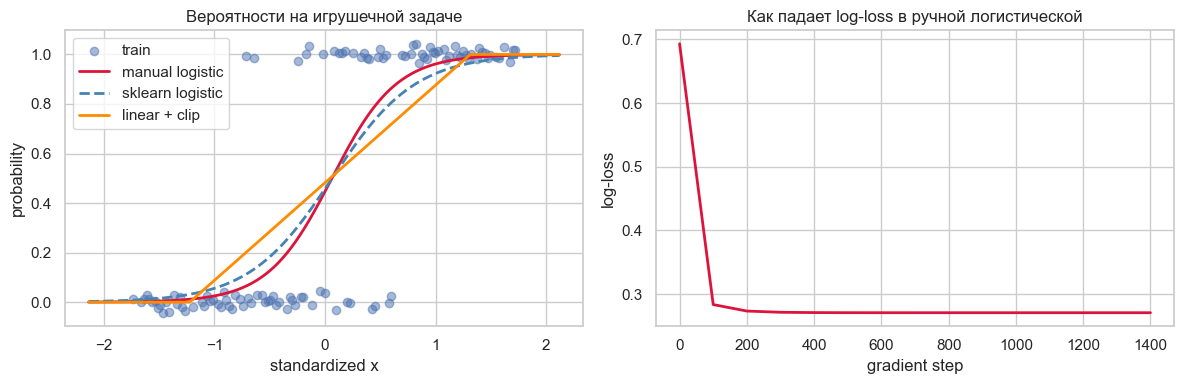

Макс. разница manual vs sklearn probabilities: 0.0575


In [11]:
grid = np.linspace(X_train_std.min() - 0.4, X_train_std.max() + 0.4, 300).reshape(-1, 1)
manual_curve = predict_logistic_manual(grid, w_log_manual)
sk_curve = log_sklearn.predict_proba(grid)[:, 1]
linear_curve = np.clip(lin_bad.predict(grid), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_train_std[:, 0], y_train + np.random.normal(0, 0.02, size=len(y_train)), alpha=0.5, label="train")
axes[0].plot(grid[:, 0], manual_curve, color="crimson", linewidth=2, label="manual logistic")
axes[0].plot(grid[:, 0], sk_curve, color="steelblue", linestyle="--", linewidth=2, label="sklearn logistic")
axes[0].plot(grid[:, 0], linear_curve, color="darkorange", linewidth=2, label="linear + clip")
axes[0].set_title("Вероятности на игрушечной задаче")
axes[0].set_xlabel("standardized x")
axes[0].set_ylabel("probability")
axes[0].legend()

steps_axis = np.arange(len(history)) * 100
axes[1].plot(steps_axis, history, color="crimson", linewidth=2)
axes[1].set_title("Как падает log-loss в ручной логистической")
axes[1].set_xlabel("gradient step")
axes[1].set_ylabel("log-loss")

plt.tight_layout()
plt.show()

print("Макс. разница manual vs sklearn probabilities:", round(np.max(np.abs(p_manual - p_sklearn)), 4))

## 8. Карта соответствий: формула -> код

### Линейная регрессия

- Формула модели: $\hat{{y}} = w^T x$
- Код: `manual_linear_predict(X, w)`
- Формула решения: $w^* = (X^T X)^{{-1}} X^T y$
- Код: `manual_linear_weights(X, y)`
- Формула ошибки: $\text{{MSE}} = \frac{{1}}{{n}} \sum (y - \hat{{y}})^2$
- Код: `mse_manual(y_true, y_pred)`

### Логистическая регрессия

- Формула вероятности: $p(x) = \sigma(w^T x)$
- Код: `predict_logistic_manual(X, w)`
- Формула сигмоиды: $\sigma(z) = 1 / (1 + e^{{-z}})$
- Код: `sigmoid(z)`
- Формула ошибки: $-\frac{{1}}{{n}} \sum [y \log p + (1-y) \log(1-p)]$
- Код: `logloss_manual(y_true, prob)`

### Что важно понять

Когда вы смотрите на код ниже уровня библиотек, формулы из презентации перестают быть абстрактными. Они буквально становятся строками Python.